### Calibration of temperature sensor chain Pipe1: temperature and pressure sensors ###

See other version in D:\Work\_Python3\And0K\tcm_cnv!

In [ ]:
from datetime import datetime
import numpy as np
from numpy.polynomial import Polynomial as Poly, polynomial as p
# import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import sys
try:
    from ruamel.yaml import YAML
    yaml = YAML()
    yaml.indent(mapping=2, sequence=4, offset=2)
    # yaml.explicit_start=False
except ImportError:
    import yaml

In [2]:
paths_in = [
    Path(r"D:\WorkData\experiment\termochain\pipe\selT@ch_pipe2_ref_SST48mc.csv"),
    Path(r"D:\WorkData\experiment\termochain\pipe\selP@ch_pipe2_ref_SST48mc.csv"),
]
coef_order = [1, 2]

coefs = {o: {} for o in coef_order}
fits = {o: {} for o in coef_order}
datas = {}
raw_names = {}
for i_ref, path_in in enumerate(paths_in):
    print(f"{i_ref+1}. Loading {path_in}...")
    with path_in.open() as f:  # Load data and column names
        col = {c: i for i, c in enumerate(f.readline().strip().split(", "))}
        cols_t = np.int8([i for i, c in enumerate(col.keys()) if c.startswith("T_")])
        data = np.genfromtxt(f, delimiter=",", dtype=np.dtype(
            [(c, ("M8[s]" if c == "Time" else "f8")) for c in list(col.keys())[:cols_t[0]]] +
            [('t_ch', 'f8', (cols_t.size,))]
        ))
    time = data["Time"]
    if "selT" in path_in.stem:
        col_ref = "Tref"
        isort_ref = np.argsort(data[col_ref])
        raw = data["t_ch"].T[:, isort_ref]
        raw_names[col_ref] = list(col.keys())[cols_t[0] :]
    else:
        col_ref = "Pref"
        isort_ref = np.argsort(data[col_ref])
        raw_names[col_ref] = list(col.keys())[cols_t[0] - 1]
        raw = np.atleast_2d(data[raw_names[col_ref]])[:, isort_ref]  # P00 or P01
    datas[col_ref] = data
    ref = data[col_ref][isort_ref]
    for o in coef_order:
        coefs[o][col_ref] = []
        fits[o][col_ref] = []
    for i, (param, x) in enumerate(zip(raw_names[col_ref], raw)):
        for o in coef_order:  # each o fit
            poly = Poly.fit(x, ref, o)
            coef = poly.convert().coef
            coefs[o][col_ref].append(coef)
            fit = p.polyval(x, coef)
            fits[o][col_ref].append(fit)
            resid = fit - ref
            print(f"{i}.order={o}. {param}:", resid, f"={fit}-{ref}")

1. Loading D:\WorkData\experiment\termochain\pipe\selT@ch_pipe2_ref_SST48mc.csv...
0.order=1. T_K: [-0.02491545  0.03568139 -0.01076594] =[ 4.71708455  7.54368139 14.08523406]-[ 4.742  7.508 14.096]
0.order=2. T_K: [4.44089210e-15 4.44089210e-15 3.55271368e-15] =[ 4.742  7.508 14.096]-[ 4.742  7.508 14.096]
1.order=1. T_L: [-0.00555911  0.00790815 -0.00234904] =[ 4.73644089  7.51590815 14.09365096]-[ 4.742  7.508 14.096]
1.order=2. T_L: [1.77635684e-15 8.88178420e-16 0.00000000e+00] =[ 4.742  7.508 14.096]-[ 4.742  7.508 14.096]
2.order=1. T_M: [-0.02406895  0.03445897 -0.01039001] =[ 4.71793105  7.54245897 14.08560999]-[ 4.742  7.508 14.096]
2.order=2. T_M: [-5.32907052e-15 -2.66453526e-15 -5.32907052e-15] =[ 4.742  7.508 14.096]-[ 4.742  7.508 14.096]
3.order=1. T_N: [-0.01603021  0.0228862  -0.006856  ] =[ 4.72596979  7.5308862  14.089144  ]-[ 4.742  7.508 14.096]
3.order=2. T_N: [-3.55271368e-15 -8.88178420e-16 -5.32907052e-15] =[ 4.742  7.508 14.096]-[ 4.742  7.508 14.096]
4.order

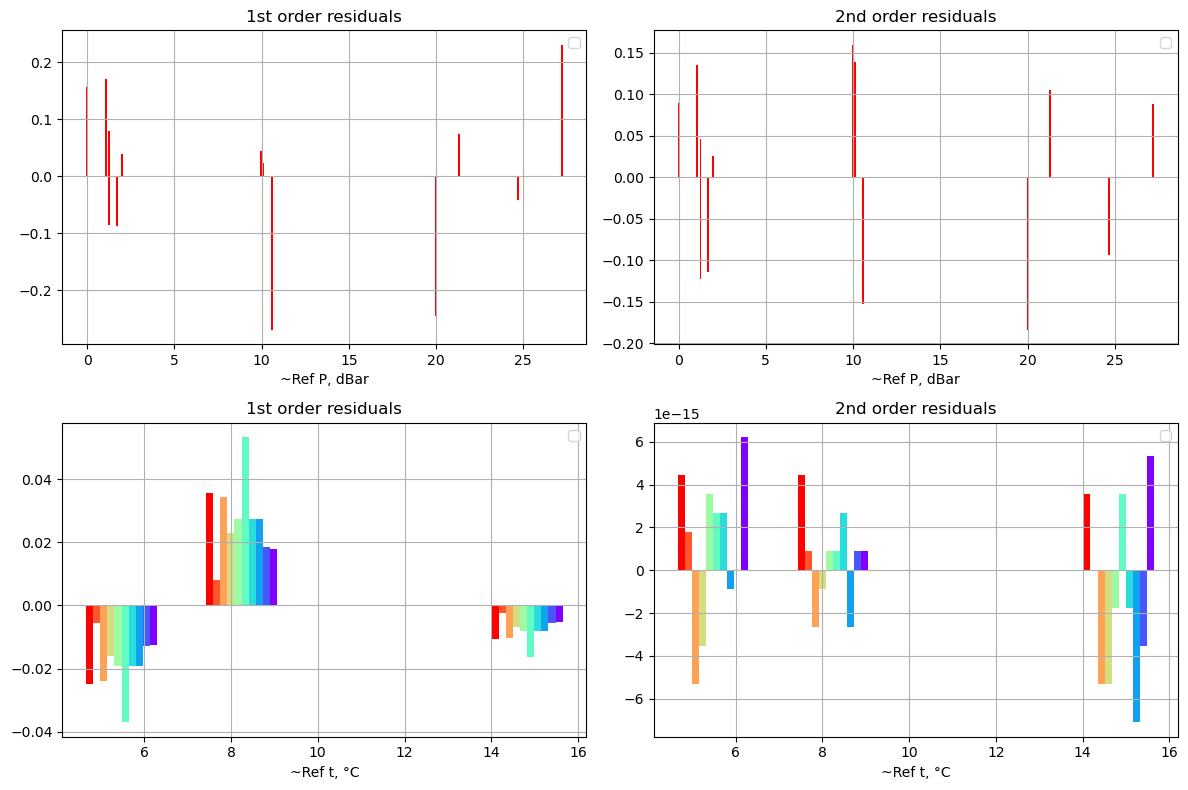

In [4]:
# Plot

n_ax_rows = len(paths_in)  # number param types
i_param_t_st = 1
fig, ax = plt.subplots(n_ax_rows, 2, figsize=(12, 4 * n_ax_rows))


# ptp_p, ptp_t = np.ptp(p), np.ptp(t)  # u_max - u_min, t_max - t_min  # ptp_u = np.ptp()
b_titles_set = False
for i_ref, (col_ref, params) in enumerate(raw_names.items()):
    colors = cm.rainbow(np.linspace(0, 1, len(params) + 1 - 1)[::-1])
    # reverse colors if last temp lower  # plt.cm.get_cmap().colors
    data = datas[col_ref]
    isort_ref = np.argsort(data[col_ref])
    ref = data[col_ref][isort_ref]
    if col_ref == "Pref":
        i_ax_row = 0
        raw = np.atleast_2d(data[params])[:, isort_ref]  # P00 or P01
        scale_bar_width = 1 / 2000000
    else:
        # i_ref == i_param_t_st:  # to not repeat same assignment to t
        raw = data["t_ch"].T[:, isort_ref]
        i_ax_row = 1
        scale_bar_width = 1 / 60
    x_min, x_max = raw.min(), raw.max()
    ptp_x = x_max - x_min
    for i_o, o in enumerate(coef_order):  # each o fit
        ax[i_ax_row, i_o].legend([params])
        ax[i_ax_row, i_o].set_xlabel("~Ref P, dBar" if col_ref == "Pref" else "~Ref t, °C")
        # b_titles_set = True

        # Plot residuals
        for i, (param, x_shift, resid, clr) in enumerate(
            zip(params, ptp_x * (np.arange(len(params)) * scale_bar_width), fits[o][col_ref] - ref, colors)
            ):
            ax[i_ax_row, i_o].bar(
                x=ref + x_shift,
                height=resid,
                width=ptp_x * scale_bar_width,
                color=clr,  # [i_ref % len(colors)], label=param
            )
        if not b_titles_set:
            ax[i_ax_row, i_o].grid()
            ax[i_ax_row, i_o].set_title(f"{o}{'st' if o == 1 else 'nd' if o == 2 else 'rd'} order residuals")


# ax.bar(x=[u_min, u_max], height=z_diff, color=c_exp)

# ax3.set_ylabel("P - P_fit, dBar")
# ax.legend(title="mean t ±Δt °C")

plt.tight_layout()
plt.savefig("regression_residuals.png")
plt.show()


In [5]:
devices = path_in.stem.split('@')[-1]
ax[0, 0].figure.savefig(path_in.with_name(f"residuals_fit({devices}).png"))

In [ ]:
# Save polynomial coefficients
for o, coefs_o in coefs.items():
    with open(path_in.with_name(f"coefficients({devices}, order={o}).txt"), "w") as f:
        f.write(
            f"Calculated {datetime.now():%Y-%m-%d} using data (first - last): {time.min().item():%Y-%m-%d %H:%M} - {time.max().item():%Y-%m-%d %H:%M}\n"
        )
        f.write(f"probe\tk0\tk1*x\t{chr(9).join([f'k{i}*x^{i}' for i in range(2, o+1)])}\n")
        for i_ref, (col_ref, params) in enumerate(raw_names.items()):
            for param, row in zip(params, coefs_o[col_ref]):
                f.write("\t".join([param] + [str(r) for r in row]) + "\n")